In [ ]:
# 3.1 Delta in menschlicher Bewertung feststellen
# 3.2 Delta Bewertung Modelle zu Mittelwert der menschlichen Bewertung feststellen
# 3.3 Delta um Delta in menschlicher Bewertung korrigieren
# 3.3 Daten nach LLM und korrigiertem Delta gruppieren, Gegenüberstellung zu "normalem" Delta generieren


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Datensätze einlesen
df_stt = pd.read_csv("llm_evaluation_combined_stt.csv")
df_normal = pd.read_csv("llm_evaluation_combined_normal.csv")

#Zeile mit fehlendem Wert (Zeile 847) löschen
df_normal=df_normal.dropna(subset=["id"])

#Komma durch Punkt ersetzen in llm_rating
df_normal["llm_rating"] = df_normal["llm_rating"].str.replace(",",".",regex=False)
df_stt["human_score"] = df_stt["human_score"].astype(str).str.split("/").str[0]
df_stt["llm_rating"] = df_stt["llm_rating"].astype(str).str.split("/").str[0]
df_stt["llm_rating"] = df_stt["llm_rating"].str.replace(",",".",regex=False)

# ID in df_normal zu integer konvertieren
df_normal["id"] = df_normal["id"].astype(int)
df_normal["id"] = df_normal["id"].astype("category")

# llm_rating in df_normal zu float konvertieren
df_normal["llm_rating"] = df_normal["llm_rating"].astype(float)

df_normal.head()
df_stt.head()



10

In [20]:
#filtern der Datensätz, die jeweils von allen 3 Gruppenmitgliedern gleich gesprochen worden sind
id_list=[3,5,14,22,28,35,39,42,47,49] 

df_normal_filtered = df_normal[df_normal["id"].isin(id_list)].copy()
df_normal_filtered["id"].nunique()

result_human = (df_normal_filtered.groupby("id")["human_score"].agg(min_score="min",max_score="max"))
result_human["score_diff"]=result_human["max_score"]-result_human["min_score"]
result_human = result_human.reset_index()
result_human.head(10)

/tmp/ipykernel_116757/2707251044.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_human = (df_normal_filtered.groupby("id")["human_score"].agg(min_score="min",max_score="max"))


,id,min_score,max_score,score_diff
0,3,2.0,4.5,2.5
1,5,6.0,6.0,0.0
2,14,4.0,4.0,0.0
3,22,6.0,6.0,0.0
4,28,0.0,1.0,1.0
5,35,1.0,2.5,1.5
6,39,3.5,4.0,0.5
7,42,4.0,6.0,2.0
8,47,2.5,4.0,1.5
9,49,3.0,4.5,1.5


In [21]:
result_llm = (df_normal_filtered.groupby(["id","model"])["llm_rating"].agg(min_score="min",max_score="max"))
result_llm["score_diff"]=result_llm["max_score"]-result_llm["min_score"]
result_llm = result_llm.reset_index()
result_llm.head(50)

/tmp/ipykernel_116757/1282584000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_llm = (df_normal_filtered.groupby(["id","model"])["llm_rating"].agg(min_score="min",max_score="max"))


,id,model,min_score,max_score,score_diff
0,3,command-r7b:latest,4.5,5.5,1.0
1,3,deepseek-r1:8b,0.5,3.5,3.0
2,3,gemma3:27b,4.0,4.0,0.0
3,3,gemma3:4b,4.0,4.0,0.0
4,3,llama3.1:latest,4.0,4.5,0.5
5,3,llama3.3:latest,3.5,4.5,1.0
6,3,mistral-small3.1:latest,1.5,3.0,1.5
7,3,mixtral:latest,5.5,6.0,0.5
8,3,phi4:latest,1.0,2.5,1.5
9,5,command-r7b:latest,5.7,5.8,0.1


In [37]:
cols = result_llm.columns.tolist()
result_human["model"]="human"
result_human =result_human[cols]



result_all=pd.concat([result_llm,result_human],ignore_index=True)
result_all = result_all.sort_values(by="id",ascending=True).reset_index(drop=True)
result_all.head(100)
#result_human.head(85)

,id,model,min_score,max_score,score_diff
0,3,command-r7b:latest,4.5,5.5,1.0
1,3,phi4:latest,1.0,2.5,1.5
2,3,mixtral:latest,5.5,6.0,0.5
3,3,mistral-small3.1:latest,1.5,3.0,1.5
4,3,llama3.3:latest,3.5,4.5,1.0
...,...,...,...,...,...
95,49,llama3.1:latest,4.5,5.0,0.5
96,49,gemma3:4b,4.0,5.0,1.0
97,49,gemma3:27b,3.5,4.0,0.5
98,49,phi4:latest,3.5,3.5,0.0


<Figure size 1400x600 with 0 Axes>

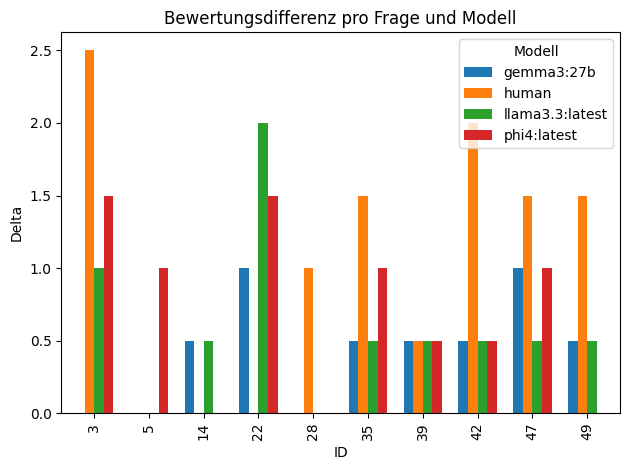

In [53]:
# Darstellen als Grafik
select_models = ["human","gemma3:27b","llama3.3:latest","phi4:latest"]
plot_df = (result_all.loc[result_all["model"].isin(select_models)].head(40).pivot(index="id",columns="model",values="score_diff").sort_index())

#plot_df = plot_df[plot_df["id"].isin(id_list)]
#plot_df = (result_all[result_all["id"].isin(id_list)].pivot(index="id",columns="model", values="score_diff").sort_index())


plt.figure(figsize=(14,6))
plot_df.plot(kind="bar",width=0.7)
plt.xlabel("ID")
plt.ylabel("Delta")
plt.title("Bewertungsdifferenz pro Frage und Modell")
plt.legend(title="Modell")
plt.tight_layout()
plt.show()

In [ ]:
#Werte aus human in llm integrieren



ValueError: value_name (score_diff) cannot match an element in the DataFrame columns.